In [ ]:
import sys
import os
import os
import phydrus as ps
import numpy as np
import warnings
import pandas as pd 
import os
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from model_build import InfiltrationModel

In [27]:
# Folder for Hydrus files to be stored
ws = "example_3"
# Path to folder containing hydrus.exe 
exe = os.path.join('/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus')
# Description
desc = "Root water uptake in a soil profile"
# Create model
ml = ps.Model(exe_name=exe, ws_name=ws, name="model", description=desc, 
              mass_units="mmol", time_unit="days", length_unit="cm")
ml.basic_info["lFlux"] = True
ml.basic_info["lShort"] = False
time = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 30]
ml.add_time_info(tmax=30, print_array=time, dt=0.001)
ml.add_waterflow(model=3, top_bc=3, bot_bc=0)
m = ml.get_empty_material_df(n=1)
m.loc[[1]] = [[0.068, 0.38, 0.008, 1.09, 4.8, 0.5]]
ml.add_material(m)
profile = ps.profile.profile_from_file("/Users/onursahin/Flux1Dpy/test/PROFILE_example3.DAT", ws="profiles")
ml.add_profile(profile)
# Add observation nodes at depth
ml.add_obs_nodes([0, -300])
bc = {"tAtm": (3, 30), "Prec": (2, 0), "rSoil": (0.1, 0.1), "rRoot": (0.5, 1.5)}
atm = pd.DataFrame(bc, index=(3, 30))
ml.add_atmospheric_bc(atm, hcrits=0, hcrita=50000)
ml.add_root_uptake(model=0, crootmax=1, poptm=[-25], omegac=1)
ml.write_input()
ml.simulate()

INFO: Successfully wrote example_3/SELECTOR.IN
INFO: Successfully wrote example_3/PROFILE.DAT
INFO: Successfully wrote example_3/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


CompletedProcess(args=['/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus', 'example_3', '-1'], returncode=0)

In [ ]:
profile_df = ml.profile

print(profile_df)
active_roots = profile_df[profile_df["Beta"] > 0]
if not active_roots.empty:
    # Assuming the soil surface is at x=0 and depth goes negative downwards:
    # The maximum depth of the roots is the absolute value of the minimum 'x'
    root_depth = (active_roots["x"].min())
    print(active_roots.loc[active_roots['x']==root_depth])
    print(f"\nCalculated Root Depth: {root_depth} cm")
else:
    print("\nNo active roots found (beta is 0 everywhere).")

In [19]:
hydrus_res = ml.read_nod_inf()

df_t = hydrus_res[0]
print(df_t['Sink'].values)
pond_max= 0.0
#flux = np.zeros(22, dtype=np.float64)
discretize = {"layers": [49, 51], "dz": [1.0, 1.0]} # dummy for this case used from the profle dat from HYDRUS for comparison

flux = np.zeros(30,dtype=float)
trans = np.zeros(30,float)
flux[0:3],flux[3:] = -1.9/1440,0.1/1440
trans[0:3],trans[3:] = 0.5/1440, 1.5/1440
temp_time  = 1440.0
sim_time = temp_time * flux.shape[0]
flux_bot = np.zeros(flux.shape)
head_bot,head_top = np.zeros(flux.shape),np.ones(flux.shape)
m.loc[[1]] = [[0.068, 0.38, 0.008, 1.09, 4.8, 0.5]]
bound_bot = 'constant head'
bound_top = 'atmospheric'
soil_props = {"tr":[0.068],"ths":[0.38],"a":[0.008],"n": [1.09], "m":[1 - (1 / 1.09)], "ks":[4.8 / 1440], "L":[0.5]}
hyd_model = 'VGM-AE'
model = InfiltrationModel(sim_time,temp_time,discretize) #create the model!
model.z = (df_t["Depth"] - df_t["Depth"].min()).values
model.z = model.z[::-1]
feddes_params = response_feddes = {"p0": -10, "p0opt": -25, "p2h": -200, "p2l": -800,
                   "p3": -8000,"r2h":0.5 / 1440,"r2l":0.1/1440 }

hini = df_t['Head'].values[::-1]
root_depth = 200.0 # cm surface to bottom 
root_dist = "uniform" # second option is "uniform"
model.set_soil_model(hyd_model,soil_props,test=True)
model.set_root_model('feddes',feddes_params,root_dist,200)
model.bx[-1] = 0
model.set_boundary_conditions(hini,bound_top,bound_bot,pond_max)
hout,sout,sink_out = model.set_run_solver(hini,flux,flux_bot,head_top,head_bot,trans)


[0.       0.002443 0.002443 0.002444 0.002444 0.002444 0.002444 0.002444
 0.002445 0.002445 0.002445 0.002446 0.002446 0.002446 0.002447 0.002447
 0.002448 0.002448 0.002448 0.002449 0.002449 0.00245  0.002451 0.002451
 0.002452 0.002452 0.002453 0.002454 0.002454 0.002455 0.002456 0.002456
 0.002457 0.002458 0.002459 0.002459 0.00246  0.002461 0.002462 0.002463
 0.002464 0.002464 0.002465 0.002466 0.002467 0.002468 0.002469 0.00247
 0.002471 0.002472 0.002474 0.002475 0.002475 0.002475 0.002475 0.002475
 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475
 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475
 0.002475 0.002475 0.002475 0.002475 0.002475 0.002475 0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.      

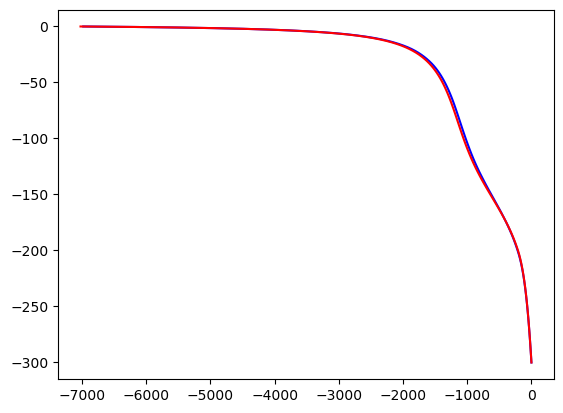

In [ ]:

hydrus_res = ml.read_nod_inf()
t = 10
plt.figure()
s_hyd = hydrus_res[t]
plt.plot(s_hyd['Sink'],s_hyd['Depth'],color='blue')
plt.plot(hout[int(t),:],s_hyd['Depth'][::-1],color='red')
plt.show()